# Pointing Cut Example

This example reads a DC4 unbinned source FITS file, builds good time intervals for a source using a 60 degree field-of-view cut, and writes a binned `.hdf5` file containing events either inside or outside that FOV selection.

The FOV selection uses `GoodTimeInterval.from_pointing_cut`, with the default example value `max_offaxis = 60 * u.deg`, to keep events when the source is inside the FOV.

**When making a pointing cut in an analysis (e.g., spectral analysis), the data, background, and orientation files need to all be cut self-consistently.**

In [ ]:
from pathlib import Path
import numpy as np
import astropy.units as u
from astropy.coordinates import SkyCoord
from astropy.time import Time
import matplotlib.pyplot as plt
from histpy import Histogram

from cosipy import BinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.util import fetch_wasabi_file

%matplotlib inline

In [ ]:
fetch_wasabi_file(
    "COSI-SMEX/DC4/Data/Mock_Dataset/dc4_mock_dataset_3months_unbinned_data_filtered_with_SAAcut_time_ordered.fits.gz",
    checksum="762b7ad849b501ddaa31799ec19d14b9",
)

fetch_wasabi_file(
    "COSI-SMEX/DC4/Data/Backgrounds/Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz",
    checksum="73c8b23e43684da3b35c25499254202b",
)

fetch_wasabi_file(
    "COSI-SMEX/DC4/Data/Orientation/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits",
    checksum="ca94ff1d7a73c1f41479aaf598807673",
)

In [ ]:
### Input files to apply pointing cuts
data_file = Path(
    "dc4_mock_dataset_3months_unbinned_data_filtered_with_SAAcut_time_ordered.fits.gz"
)

bkg_file = Path(
    "Total_DC4_BG_3months_unbinned_data_filtered_with_SAAcut_withSAAbck.fits.gz"
)

orientation_file = Path(
    "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.fits"
)

### Output names for the binned files after the pointing cut
binned_output_file = Path(
    "dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5"
)
binned_bkg_output_file = Path(
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5"
)

### This config is only used to initialize the DataIO object
config_file = Path("inputs.yaml")

Change details below for the source to be analyzed

In [3]:
source_name = "NGC 4151"
source_coord = SkyCoord(l=155.07 * u.deg, b=75.06 * u.deg, frame="galactic")

### Default FOV cut used by the pointing-cut helper.
max_offaxis = 60 * u.deg
earth_occ = True

Read the unbinned FITS data and open the spacecraft orientation over the event time range.

In [4]:
analysis = BinnedData(str(config_file))

analysis.cosi_dataset = analysis.get_dict(str(data_file))
time_tags = analysis.cosi_dataset["TimeTags"]

Load in the orientation file.


In [5]:
orientation = SpacecraftHistory.open(orientation_file)

print(f"Time-cut orientation pointings: {len(orientation.obstime):,}")

Time-cut orientation pointings: 531,998


Build the GTIs where the source is inside the FOV.

In [6]:
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    orientation,
    max_offaxis,
    earth_occ=earth_occ,
)

pointing_cut_orientation = orientation.apply_gti(source_gti)
gti_livetime = pointing_cut_orientation.cumulative_livetime().to_value(u.s)
total_livetime = orientation.cumulative_livetime().to_value(u.s)
livetime_fraction = gti_livetime / total_livetime

print(f"Source: {source_name}")
print(f"FOV cut: off-axis <= {max_offaxis.to_value(u.deg):.1f} deg")
print(f"GTI intervals: {len(source_gti)}")
print(f"GTI livetime: {gti_livetime:,.1f} s")
print(f"Total livetime: {total_livetime:,.1f} s")
print(f"Livetime fraction in FOV: {livetime_fraction:.4f}")

Source: NGC 4151
FOV cut: off-axis <= 60.0 deg
GTI intervals: 675
GTI livetime: 980,415.0 s
Total livetime: 6,579,555.0 s
Livetime fraction in FOV: 0.1490


Apply the GTI to the mock-data file. This uses the same half-open convention as `select_data_time`: events are kept for `start <= TimeTags < stop`.


In [7]:
in_fov_mask = source_gti.contains(analysis.cosi_dataset["TimeTags"])
n_in_fov = np.count_nonzero(in_fov_mask)
n_out_fov = len(in_fov_mask) - n_in_fov

analysis.cosi_dataset = {
    key: values[in_fov_mask]
    for key, values in analysis.cosi_dataset.items()
}
selected_time_tags = analysis.cosi_dataset["TimeTags"]
analysis.tmin = float(np.min(selected_time_tags))
analysis.tmax = float(np.max(selected_time_tags))

print(f"Events in FOV: {n_in_fov:,}")
print(f"Events outside FOV: {n_out_fov:,}")

Events in FOV: 26,164,190
Events outside FOV: 156,163,781


In [8]:
analysis.get_binned_data(
    make_binning_plots=False,
    show_plots=False,
)
analysis.binned_data.write(binned_output_file, overwrite=True)

print(f"Wrote: {binned_output_file}")

del analysis.cosi_dataset, analysis.binned_data, in_fov_mask

Wrote: dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_time_ordered.hdf5


Apply the same pointing-cut time intervals to the background file, following the same unbinned-selection and binning pattern used in the other tutorial notebooks.


In [9]:
background = BinnedData(str(config_file))

background.cosi_dataset = background.get_dict(str(bkg_file))
bkg_in_fov_mask = source_gti.contains(background.cosi_dataset["TimeTags"])

background.cosi_dataset = {
    key: values[bkg_in_fov_mask]
    for key, values in background.cosi_dataset.items()
}
selected_bkg_time_tags = background.cosi_dataset["TimeTags"]
background.tmin = float(np.min(selected_bkg_time_tags))
background.tmax = float(np.max(selected_bkg_time_tags))

background.get_binned_data(
    make_binning_plots=False,
    show_plots=False,
)
background.binned_data.write(binned_bkg_output_file, overwrite=True)

print(f"Background events in FOV: {np.count_nonzero(bkg_in_fov_mask):,}")
print(f"Background events outside FOV: {len(bkg_in_fov_mask) - np.count_nonzero(bkg_in_fov_mask):,}")
print(f"Wrote: {binned_bkg_output_file}")

del background.cosi_dataset, background.binned_data, bkg_in_fov_mask

fill() discarded one or more values due to out-of-bounds coordinate in a dimension without under/overflow tracking


Background events in FOV: 25,071,036
Background events outside FOV: 143,577,508
Wrote: Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck.hdf5


Load the saved pointing-cut binned files and compare the mock-data and background counts.


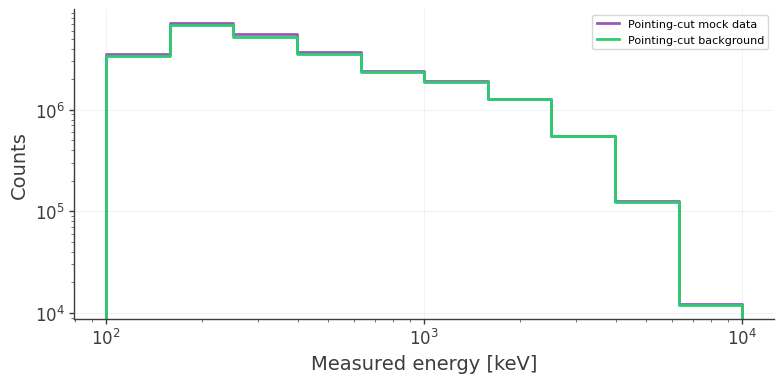

In [ ]:
mock_hist = Histogram.open(binned_output_file)
background_hist = Histogram.open(binned_bkg_output_file)

mock_energy_counts = mock_hist.project("Em")
background_energy_counts = background_hist.project("Em")

fig, ax = plt.subplots(figsize=(8, 4))

mock_energy_counts.draw(
    ax=ax,
    label="Pointing-cut mock data",
    linewidth=2,
)
background_energy_counts.draw(
    ax=ax,
    label="Pointing-cut background",
    linewidth=2,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Measured energy [keV]")
ax.set_ylabel("Counts")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()

Save the pointing cut orientation file if needed. The time cut can be performed and used on the orientation file in analysis directy as shown above.

In [ ]:
orientation_output_file = "DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA_NGC4151_cut"
pointing_cut_orientation.write_fits(orientation_output_file, overwrite=True)
print(f"Wrote: {orientation_output_file}")